In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from matplotlib.transforms import offset_copy

from scipy.cluster.hierarchy import fcluster, linkage, dendrogram, cut_tree, leaves_list
from scipy.spatial.distance import pdist, squareform

In [11]:
%run LittRuP__import_functions.ipynb

In [12]:
# chemins vers fichiers Data et Images

BASE_DIR = Path.cwd()

if BASE_DIR.name == "Notebooks":
    BASE_DIR = BASE_DIR.parent

DAT_DIR = BASE_DIR / "Data"
IMG_DIR = BASE_DIR / "Images"
DOC_DIR = BASE_DIR / "Docs"

In [13]:
# import matrice étendue

matrix_all_extended = pd.read_csv(DAT_DIR / "LittRu_matrix_all_extended.csv", sep=',', header=0)

In [14]:
# SELECTION de la matrice des identifiants étendus (Works...->)

cols_ids_extended = ["Works", "Author", "Birth", "Death", "Period", "Composed", "When", "Name", "CutOff"]

matrix_ids_extended = matrix_all_extended[cols_ids_extended]

In [15]:
# indique que les thèmes sont toutes les colonnes situées après "CutOff"

theme_cols = matrix_all_extended.columns[
    matrix_all_extended.columns.get_loc("CutOff") + 1:
]

**Dendrogramme des auteurs**

In [16]:
# profil thématique par auteur

matrix_author_profile = (
    matrix_all_extended
    .groupby("Author")[theme_cols]   # Regrouper les lignes (thèmes) appartenant au même auteur (=> mis en INDEX !)
    .sum()                           # appliquer une somme colonne par colonne à l’intérieur de chaque groupe d’auteur
)

In [17]:
# calcul des distances

dist_authors = pdist(
    matrix_author_profile,
    metric="cosine"
)

Z = linkage(
    dist_authors,
    method="average"
)

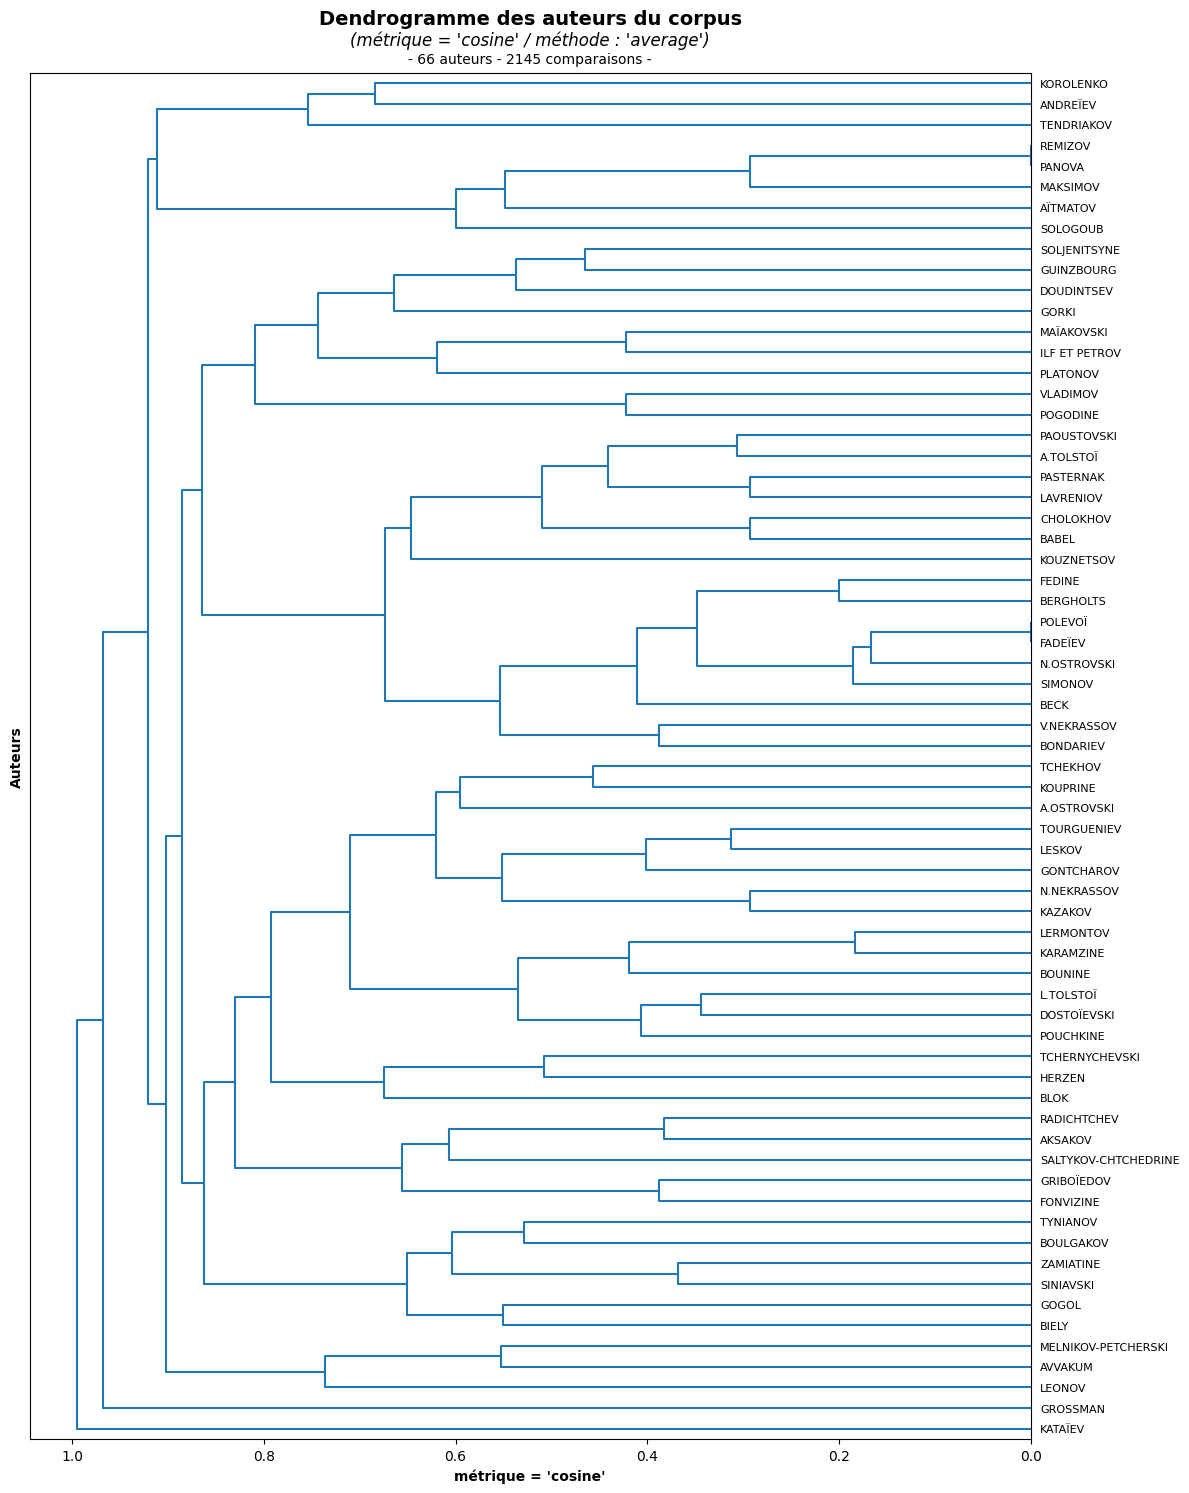

In [18]:
# dendrogramme

fig, ax = plt.subplots(figsize=(12, 16))

dendrogram(
    Z,
    labels=matrix_author_profile.index,
    leaf_rotation=0, 
    leaf_font_size=8,
    orientation="left",
    color_threshold=0
)

N_authors = len(matrix_author_profile.index)
N_dist = len(dist_authors) 

ax.set_ylabel("Auteurs", fontweight="bold")
ax.set_xlabel("métrique = 'cosine'", fontweight="bold")
ax.tick_params(axis="x", labelsize=10)

fig.tight_layout(rect=[0, 0, 1, 0.90])

titres(
    fig,
    ax,
    t1="Dendrogramme des auteurs du corpus", y1=35,
    t2="(métrique = 'cosine' / méthode : 'average')", y2=20,
    t3=f"- {N_authors} auteurs - {N_dist} comparaisons -", y3=7
)

fig.savefig(IMG_DIR / "auteurs_dendrogramme.png", dpi=300)

plt.show()